In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 


In [10]:
file_path="../data/raw/online_retail_II.xlsx" 
excel_data=pd.read_excel(
    file_path,
    sheet_name=None
)

excel_data.keys()

dict_keys(['Year 2009-2010', 'Year 2010-2011'])

In [11]:
df=pd.concat(
    excel_data.values(),
    ignore_index=True
)

In [12]:
df.head()
df.tail()
df.sample(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
610642,543467,84598,BOYS ALPHABET IRON ON PATCHES,13,2011-02-08 14:35:00,0.42,NaN,United Kingdom
162330,504887,22276,WASH BAG VINTAGE ROSE PAISLEY,12,2010-04-18 13:40:00,2.10,17850.0,United Kingdom
121207,500979,84709B,PINK OVAL JEWELLED MIRROR,2,2010-03-11 13:16:00,5.95,14172.0,United Kingdom
862398,566408,21539,RED RETROSPOT BUTTER DISH,1,2011-09-12 13:43:00,4.95,16984.0,United Kingdom
939312,572326,20685,DOORMAT RED RETROSPOT,10,2011-10-24 09:55:00,7.08,14607.0,United Kingdom


In [13]:
df.describe()
df.describe(include='all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371.0,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628.0,5305,5698,NaN,NaN,NaN,NaN,43
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1350.0,5829,5918,NaN,NaN,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504,NaN
min,NaN,NaN,NaN,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000,NaN
max,NaN,NaN,NaN,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000,NaN


In [14]:
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [15]:
missing=df.isnull().sum()
missing

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [16]:
missing_percentage=(
    df.isnull().mean()*100
).sort_values(ascending=False)
missing_percentage

Customer ID    22.766873
Description     0.410541
StockCode       0.000000
Invoice         0.000000
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Country         0.000000
dtype: float64

In [17]:
missing_report=pd.DataFrame({
    "missing_count":df.isnull().sum(),
    "missing_percentage":df.isnull().mean()*100
})
missing_report=missing_report.sort_values(
    "missing_percentage",
    ascending=False
)
missing_report

,missing_count,missing_percentage
Customer ID,243007,22.766873
Description,4382,0.410541
StockCode,0,0.000000
Invoice,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Country,0,0.000000


In [18]:
duplicate_count=df.duplicated().sum()
duplicate_count

np.int64(34335)

In [19]:
duplicate_percentage=(
    df.duplicated().mean()*100
)
duplicate_percentage

np.float64(3.2167821685243467)

In [20]:
df.nunique().sort_values()

Country           43
Quantity        1057
Price           2807
StockCode       5305
Description     5698
Customer ID     5942
InvoiceDate    47635
Invoice        53628
dtype: int64

In [22]:
df["Country"].nunique()
df["Country"].value_counts().head(20)

Country
United Kingdom     981330
EIRE                17866
Germany             17624
France              14330
Netherlands          5140
Spain                3811
Switzerland          3189
Belgium              3123
Portugal             2620
Australia            1913
Channel Islands      1664
Italy                1534
Norway               1455
Sweden               1364
Cyprus               1176
Finland              1049
Austria               938
Denmark               817
Unspecified           756
Greece                663
Name: count, dtype: int64

In [23]:
df["StockCode"].nunique()
df["Customer ID"].nunique()
df["Invoice"].nunique()

53628

In [26]:
df["Invoice"].astype(str).str.startswith("C").value_counts()
cancelled=df[
    df["Invoice"].astype(str).str.startswith("C")
]
cancelled.shape
cancelled.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [27]:
(df["Quantity"]<0).sum()
df[df["Quantity"]<0].head()
(df["Price"]<0).sum()

np.int64(5)

In [28]:
df["InvoiceDate"].min()
df["InvoiceDate"].max()
df["InvoiceDate"].isna().sum()


np.int64(0)

In [31]:
df["Revenue"]=df["Quantity"]*df["Price"]
df[["Quantity","Price","Revenue"]].head()
df["Revenue"].describe()
df["Revenue"].sum()

np.float64(19287250.568)

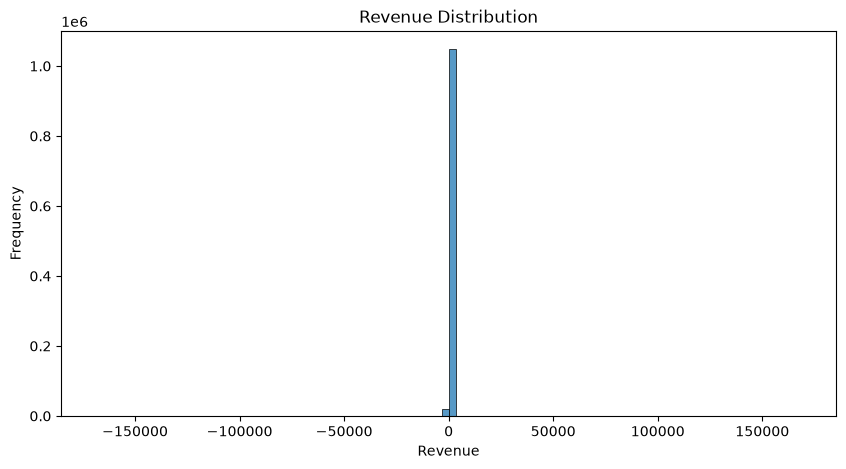

In [32]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Revenue"],
    bins=100
)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

In [33]:
profiling_report = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    "duplicate_rows": int(df.duplicated().sum()),
    "total_missing_values": int(df.isnull().sum().sum()),
    "unique_customers": int(df["Customer ID"].nunique()),
    "unique_products": int(df["StockCode"].nunique()),
    "unique_invoices": int(df["Invoice"].nunique()),
    "unique_countries": int(df["Country"].nunique()),
    "total_revenue": float(df["Revenue"].sum())
}

profiling_report

{'rows': 1067371,
 'columns': 9,
 'duplicate_rows': 34335,
 'total_missing_values': 247389,
 'unique_customers': 5942,
 'unique_products': 5305,
 'unique_invoices': 53628,
 'unique_countries': 43,
 'total_revenue': 19287250.568}